# Scenario: ShopSmart’s Free Shipping Experiment

ShopSmart wants to know whether offering free shipping leads customers to spend more per order.

They randomly assign customers to two groups:

- Group A (Control): standard shipping cost applies

- Group B (Variant): free shipping offered at checkout

The company wants to know whether free shipping increases the average order value (AOV).

Data: shop_smart_exercise.csv


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import scipy.stats as sps
from statsmodels.stats.api import proportion_confint

In [5]:
df=pd.read_csv("../data/shop_smart_exercise.csv")

In [6]:
df

,group,AOV
0,A,85.960570
1,A,78.340828
2,A,87.772262
3,A,98.276358
4,A,77.190160
...,...,...
795,B,95.637834
796,B,82.525338
797,B,91.178008
798,B,83.339821


In [7]:
df['group'].value_counts()

group
A    400
B    400
Name: count, dtype: int64

In [8]:
#Check the group avg 
df['AOV'].groupby(df['group']).mean().round(2)

group
A    80.27
B    82.54
Name: AOV, dtype: float64

In [9]:
AOV_standard_shipping=df[df['group']=='A']['AOV']
AOV_standard_shipping

0      85.960570
1      78.340828
2      87.772262
3      98.276358
4      77.190160
         ...    
395    74.369892
396    59.442386
397    96.246468
398    78.625522
399    94.853796
Name: AOV, Length: 400, dtype: float64

In [10]:
AOV_free_shipping=df[df['group']=='B']['AOV']
AOV_free_shipping

400    63.866868
401    75.807500
402    83.062924
403    83.563767
404    77.599214
         ...    
795    95.637834
796    82.525338
797    91.178008
798    83.339821
799    83.357074
Name: AOV, Length: 400, dtype: float64

In [40]:
mean_AOV_standard_shipping=AOV_standard_shipping.mean().round(2)
print(f'average AOV of standard shipping: {mean_AOV_standard_shipping:.2f}')
mean_AOV_free_shipping=AOV_free_shipping.mean().round(2)
print(f'average AOV of free shipping: {mean_AOV_free_shipping:.2f}')

diff_mean_AOV=mean_AOV_free_shipping-mean_AOV_standard_shipping
print(f'diff: {diff_mean_AOV:.2f}')

n_AOV_standard_shipping=len(AOV_standard_shipping)
print(f'number of AOV via standard shipping: {n_AOV_standard_shipping:.2f}')
n_AOV_free_shipping=len(AOV_free_shipping)
print(f'number of AOV via free shipping: {n_AOV_free_shipping:.2f}')

std_AOV_standard_shipping=AOV_standard_shipping.std()
print(f'standard deviation of standard shipping: {std_AOV_standard_shipping:.2f}')
std_AOV_free_shipping=AOV_free_shipping.std()
print(f'standard deviation of free shipping: {std_AOV_free_shipping:.2f}')

average AOV of standard shipping: 80.27
average AOV of free shipping: 82.54
diff: 2.27
number of AOV via standard shipping: 400.00
number of AOV via free shipping: 400.00
standard deviation of standard shipping: 11.52
standard deviation of free shipping: 12.08


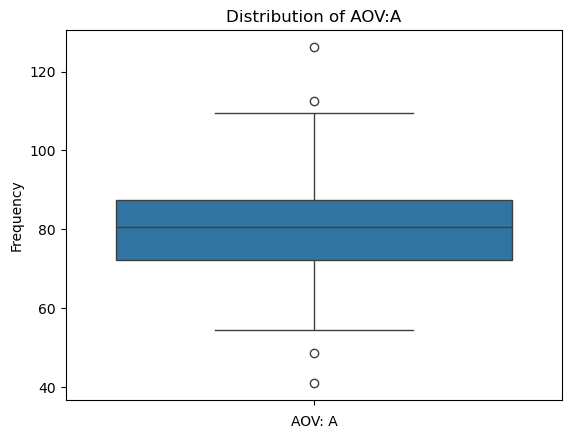

In [12]:
# plot the two groups boxplots
sns.boxplot(AOV_standard_shipping)
plt.title("Distribution of AOV:A")
plt.xlabel("AOV: A")
plt.ylabel("Frequency")
plt.show()

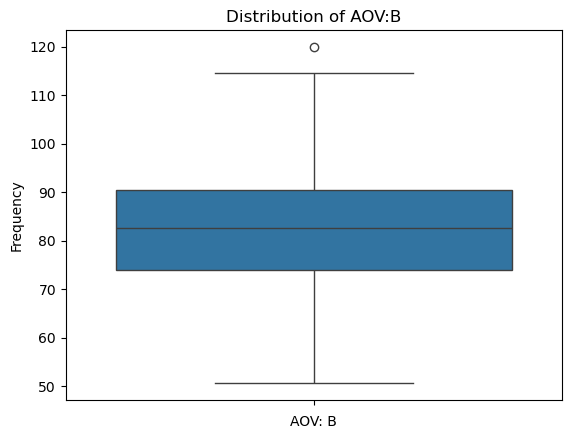

In [13]:
# plot the two groups boxplots
sns.boxplot(AOV_free_shipping)
plt.title("Distribution of AOV:B")
plt.xlabel("AOV: B")
plt.ylabel("Frequency")
plt.show()

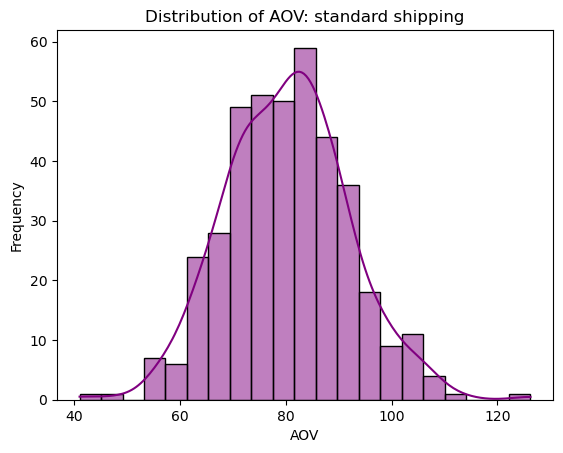

In [14]:
# plot the distributions of both groups using either histograms of displot
sns.histplot(AOV_standard_shipping, kde=True, color='purple')
plt.title("Distribution of AOV: standard shipping")
plt.xlabel("AOV")
plt.ylabel("Frequency")
plt.show()


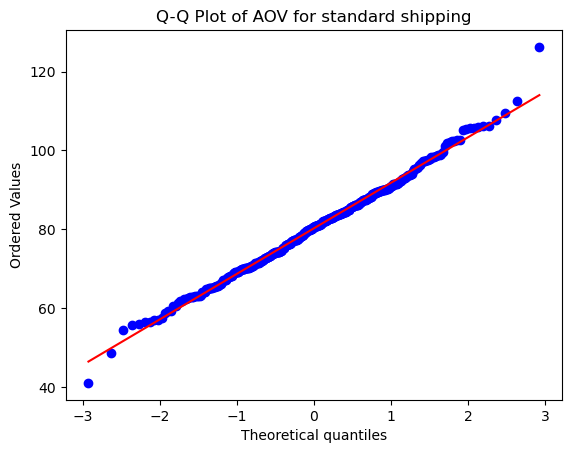

In [15]:
# Q-Q plot
stats.probplot(AOV_standard_shipping, dist="norm", plot=plt)
plt.title("Q-Q Plot of AOV for standard shipping")
plt.show()

In [16]:
_, p_value_shapiro = stats.shapiro(AOV_standard_shipping)
print(f"Shapiro-Wilk p-value: {p_value_shapiro:.3f}")

Shapiro-Wilk p-value: 0.325


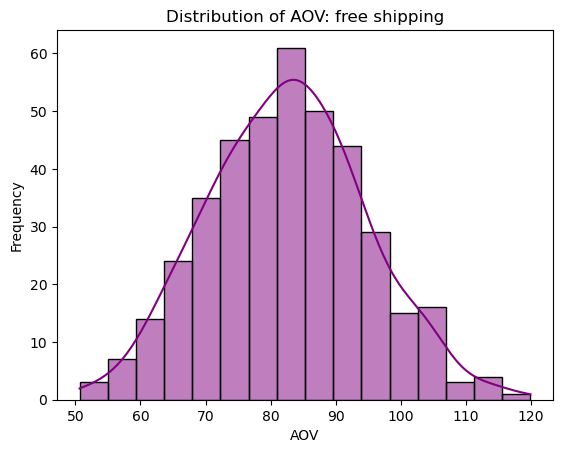

In [17]:
# plot the distributions of both groups using either histograms of displot
sns.histplot(AOV_free_shipping, kde=True, color='purple')
plt.title("Distribution of AOV: free shipping")
plt.xlabel("AOV")
plt.ylabel("Frequency")
plt.show()

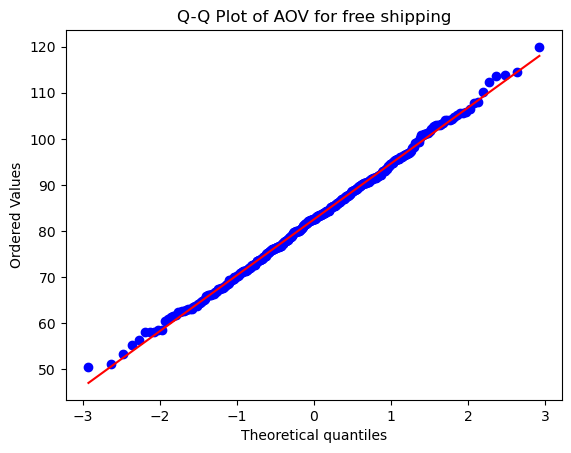

In [18]:
# Q-Q plot
stats.probplot(AOV_free_shipping, dist="norm", plot=plt)
plt.title("Q-Q Plot of AOV for free shipping")
plt.show()

In [19]:
_, p_value_shapiro = stats.shapiro(AOV_free_shipping)
print(f"Shapiro-Wilk p-value: {p_value_shapiro:.3f}")

Shapiro-Wilk p-value: 0.874


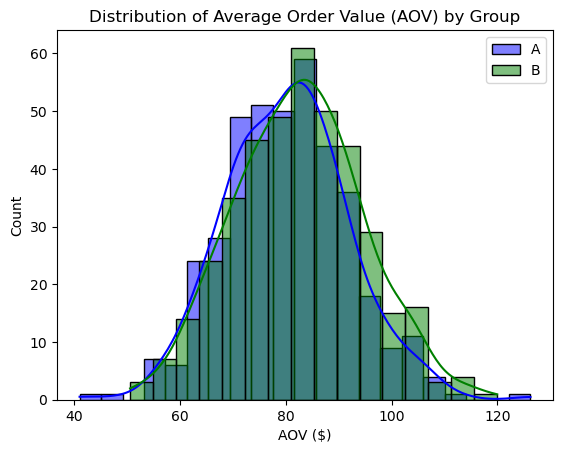

In [45]:
sns.histplot(df[df['group'] == 'A']['AOV'], kde=True, color='blue', label='A')
sns.histplot(df[df['group'] == 'B']['AOV'], kde=True, color='green', label='B')
plt.legend()
plt.title("Distribution of Average Order Value (AOV) by Group")
plt.xlabel("AOV ($)")
plt.show()

In [46]:
# t_stat, p_value = stats.ttest_ind(
#      df[df['group'] == 'B']['AOV'],
#      df[df['group'] == 'A']['AOV'],
#      alternative='greater'  # one-tailed test
# )

# print(f"T-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")

In [28]:
# apply the two-sample t-test on the data. What is the p-value?  Use a significance level of 0.05
import scipy.stats as sps

sample_standard_shipping=AOV_standard_shipping
sample_free_shipping=AOV_free_shipping

test_statistic, p_value = sps.ttest_ind(sample_free_shipping, sample_standard_shipping, alternative='greater')  # one-tailed test)

print(f'test_statistic:{test_statistic:.3f}')
print(f'p_value:{p_value:.3f}')

alpha = 0.05

if p_value < alpha:
    print(f"p = {p_value:.4f} < {alpha}, reject the null hypothesis; there is a significant difference between the two group means.")
else:
    print(f"p = {p_value:.4f} ≥ {alpha}, fail to reject the null hypothesis; the difference between the two group means is not significant.")


test_statistic:2.718
p_value:0.003
p = 0.0034 < 0.05, reject the null hypothesis; there is a significant difference between the two group means.


In [33]:
import statsmodels.stats.api as sms

cm = sms.CompareMeans.from_data(
    df[df['group'] == 'B']['AOV'],
    df[df['group'] == 'A']['AOV']
)
ci_low, ci_high = cm.tconfint_diff(alpha=0.05, usevar='pooled')
print(f"95% CI for difference in means (B - A): ({ci_low:.2f}, {ci_high:.2f})")

95% CI for difference in means (B - A): (0.63, 3.91)


In [47]:
#using z distribution to calculate the range of the group standard shipping
from scipy.stats import norm

z_score = norm.ppf(0.975) 
margin_of_error = z_score * (mean_AOV_standard_shipping/ np.sqrt(n_AOV_standard_shipping))  
ci_lower = mean_AOV_standard_shipping - margin_of_error
ci_upper = mean_AOV_standard_shipping + margin_of_error

print(f'average AOV via standard shipping: {mean_AOV_standard_shipping:.2f}')
print(f"95% Confidence Interval for the average AOV via standard shipping ({ci_lower:.2f}, {ci_upper:.2f})")

average AOV via standard shipping: 80.27
95% Confidence Interval for the average AOV via standard shipping (72.40, 88.14)


In [48]:
#using z distribution to calculate the range of the group free shipping
from scipy.stats import norm

z_score = norm.ppf(0.975) 
margin_of_error = z_score * (mean_AOV_free_shipping/ np.sqrt(n_AOV_free_shipping)) 
ci_lower = mean_AOV_free_shipping - margin_of_error
ci_upper = mean_AOV_free_shipping + margin_of_error

print(f'average AOV via free shipping: {mean_AOV_free_shipping:.2f}')
print(f"95% Confidence Interval for the average AOV via free shipping ({ci_lower:.2f}, {ci_upper:.2f})")

average AOV via free shipping: 82.54
95% Confidence Interval for the average AOV via free shipping (74.45, 90.63)


In [50]:
#using t distribution to calculate the range of the group standard shipping
from scipy.stats import t

# t-score for 95% confidence and n-1 degrees of freedom
t_score = t.ppf(0.975, df=n_AOV_standard_shipping - 1)

# margin of error using t-distribution
margin_of_error = t_score * (std_AOV_standard_shipping / np.sqrt(n_AOV_standard_shipping))

# confidence interval
ci_lower = mean_AOV_standard_shipping - margin_of_error
ci_upper = mean_AOV_standard_shipping + margin_of_error

print(f'average AOV via standard shipping: {mean_AOV_standard_shipping:.2f}')
print(f"95% Confidence Interval for the average AOV via standard shipping: ({ci_lower:.2f}, {ci_upper:.2f})")


average AOV via standard shipping: 80.27
95% Confidence Interval for the average AOV via standard shipping: (79.14, 81.40)


In [51]:
#using t distribution to calculate the range of the group free shipping
from scipy.stats import t

# t-score for 95% confidence and n-1 degrees of freedom
t_score = t.ppf(0.975, df=n_AOV_free_shipping - 1)

# margin of error using t-distribution
margin_of_error = t_score * (std_AOV_free_shipping / np.sqrt(n_AOV_free_shipping))

# confidence interval
ci_lower = mean_AOV_free_shipping - margin_of_error
ci_upper = mean_AOV_free_shipping + margin_of_error

print(f'average AOV via free shipping: {mean_AOV_free_shipping:.2f}')
print(f"95% Confidence Interval for the average AOV via free shipping: ({ci_lower:.2f}, {ci_upper:.2f})")

average AOV via free shipping: 82.54
95% Confidence Interval for the average AOV via free shipping: (81.35, 83.73)


## Step 5: Interpretation in Business Terms

TP-value interpretation:

`p = 0.003 < 0.05 → reject H₀`.

Strong evidence that free shipping increases AOV.

Confidence interval interpretation:

We are 95% confident the true increase in AOV lies between `$0.63 and $3.91`.

“Free shipping significantly boosts average order value by about $0.63 and $3.91 per customer.
This improvement is statistically significant and likely financially meaningful.
Rolling out free shipping could increase daily revenue substantially.”